# Full Strategy: AI + Graph + Markowitz (3 Regime Classification)

Notebook ini menjalankan strategi lengkap dengan **3 regime classification**:

## 🎯 **3 Regime Strategy:**
1. **🔴 Bearish Regime**: Hold 100% Cash (risk-off)
2. **🟡 Neutral Regime**: Markowitz optimization pada semua aset (moderate risk)
3. **🟢 Bullish Regime**: Graph Filter (MIS) + Markowitz optimization (full strategy)

## 📊 **Components:**
- **AI Gatekeeper**: Random Forest Classifier untuk multi-class classification (3 regime)
- **Graph Theory (MIS)**: Filter aset berdasarkan korelasi (hanya di Bullish regime)
- **Markowitz Optimization**: Portfolio optimization untuk maksimalisasi Sharpe Ratio

**Benchmark**: Buy and hold Bitcoin (BTC)

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load Data
file_path = 'dataset_2023_2025.xlsx'
if os.path.exists(file_path):
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"Loaded {len(data)} rows of data.")
else:
    print("File data tidak ditemukan! Pastikan dataset ada di folder yang sama.")

Loaded 990 rows of data.


## 1. Feature Engineering & 3-Regime Labeling

Membuat label untuk 3 regime berdasarkan market return:
- **Bearish (0)**: Market return < -threshold
- **Neutral (1)**: -threshold ≤ Market return ≤ threshold
- **Bullish (2)**: Market return > threshold

In [2]:
# Returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# 3-Regime Labeling
# Threshold untuk membedakan regime (bisa disesuaikan)
threshold = 0.001  # 0.1% daily return threshold

def create_3regime_label(ret, threshold=0.001):
    """Create 3-regime label: 0=Bearish, 1=Neutral, 2=Bullish"""
    if ret < -threshold:
        return 0  # Bearish
    elif ret > threshold:
        return 2  # Bullish
    else:
        return 1  # Neutral

features['Target'] = market_return.shift(-1).apply(lambda x: create_3regime_label(x, threshold))
features = features.dropna()

# Check distribution
print("\n=== Regime Distribution ===")
print(features['Target'].value_counts().sort_index())
print(f"\nBearish (0): {(features['Target']==0).sum()} days")
print(f"Neutral (1): {(features['Target']==1).sum()} days")
print(f"Bullish (2): {(features['Target']==2).sum()} days")


=== Regime Distribution ===
Target
0    402
1     36
2    489
Name: count, dtype: int64

Bearish (0): 402 days
Neutral (1): 36 days
Bullish (2): 489 days


## 2. Train/Test Split & AI Model Training


=== AI Model Performance ===
Accuracy: 50.96%

Classification Report:
              precision    recall  f1-score   support

     Bearish       0.46      0.23      0.31       162
     Neutral       0.00      0.00      0.00        15
     Bullish       0.52      0.79      0.63       188

    accuracy                           0.51       365
   macro avg       0.33      0.34      0.31       365
weighted avg       0.47      0.51      0.46       365



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


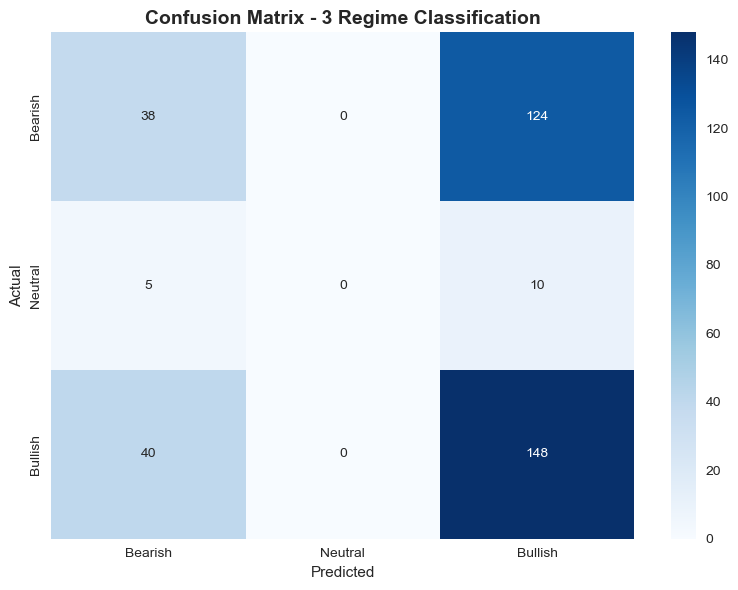

In [3]:
# Split
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)
X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test, y_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[test_mask, 'Target']

# Train Random Forest for 3-class classification
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
test_probs = rf_model.predict_proba(X_test)  # Probabilities for all 3 classes

# Model Performance
print("\n=== AI Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bearish', 'Neutral', 'Bullish']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bearish', 'Neutral', 'Bullish'],
            yticklabels=['Bearish', 'Neutral', 'Bullish'])
plt.title('Confusion Matrix - 3 Regime Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 3. Helper Functions
Fungsi untuk Graph Theory (MIS) dan Markowitz Optimization.

In [4]:
def get_mis_assets(returns_window, correlation_threshold=0.5):
    """Filter aset menggunakan Maximum Independent Set (MIS) berdasarkan korelasi."""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if corr_mat.iloc[i, j] > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_assets_returns):
    """Optimasi Markowitz untuk maksimalisasi Sharpe Ratio."""
    if len(selected_assets_returns.columns) == 0: return {}
    if len(selected_assets_returns.columns) == 1: return {selected_assets_returns.columns[0]: 1.0}
        
    mu = selected_assets_returns.mean() * 252
    sigma = selected_assets_returns.cov() * 252
    
    def neg_sharpe_ratio(weights):
        port_return = np.sum(weights * mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_return / port_volatility if port_volatility > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    initial_guess = len(mu) * [1. / len(mu)]
    
    try:
        result = minimize(neg_sharpe_ratio, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_assets_returns.columns, result.x))
    except:
        return dict(zip(selected_assets_returns.columns, initial_guess))

## 4. Full Strategy Backtest (3 Regime)

Menjalankan strategi dengan 3 regime:
- **Bearish**: 100% Cash
- **Neutral**: Markowitz pada semua aset
- **Bullish**: Graph Filter + Markowitz

In [5]:
def run_3regime_strategy(test_dates, returns, predictions, lookback=30, corr_threshold=0.5):
    """Menjalankan strategi Full dengan 3 regime classification."""
    current_value = 10000.0
    history = [current_value]
    dates = [test_dates[0]]
    regime_history = []
    
    for i, date in enumerate(test_dates[:-1]):
        # Get predicted regime (0=Bearish, 1=Neutral, 2=Bullish)
        regime = predictions[i]
        regime_history.append(regime)
        
        loc_idx = returns.index.get_loc(date)
        if loc_idx < lookback:
            weights = {t: 1.0/len(returns.columns) for t in returns.columns}
        else:
            window_returns = returns.iloc[loc_idx-lookback:loc_idx]
            
            if regime == 0:  # Bearish
                # Risk-off: Hold Cash
                weights = {'CASH': 1.0}
            elif regime == 1:  # Neutral
                # Moderate: Markowitz on all assets (no graph filter)
                weights = optimize_markowitz(window_returns)
            else:  # regime == 2, Bullish
                # Full strategy: Graph Filter + Markowitz
                selected_assets = get_mis_assets(window_returns, corr_threshold)
                weights = optimize_markowitz(window_returns[selected_assets])
        
        # Calculate daily return
        next_date = test_dates[i+1]
        next_day_rets = returns.loc[next_date]
        
        daily_ret = 0
        if 'CASH' in weights:
            daily_ret = 0
        else:
            for asset, w in weights.items():
                daily_ret += w * next_day_rets[asset]
        
        current_value *= (1 + daily_ret)
        history.append(current_value)
        dates.append(next_date)
    
    return pd.Series(history, index=dates), regime_history

# Run strategy
test_dates = X_test.index
print("Running 3-Regime Strategy (AI + Graph + Markowitz)...")
res_3regime, regime_hist = run_3regime_strategy(test_dates, returns, y_pred)

# Benchmark BTC
btc_series = data.loc[test_dates, 'BTC-USD']
btc_norm = btc_series / btc_series.iloc[0] * 10000

print("Backtest completed!")

# Regime distribution in test period
print("\n=== Regime Distribution in Test Period ===")
regime_counts = pd.Series(regime_hist).value_counts().sort_index()
print(f"Bearish (0): {regime_counts.get(0, 0)} days ({regime_counts.get(0, 0)/len(regime_hist)*100:.1f}%)")
print(f"Neutral (1): {regime_counts.get(1, 0)} days ({regime_counts.get(1, 0)/len(regime_hist)*100:.1f}%)")
print(f"Bullish (2): {regime_counts.get(2, 0)} days ({regime_counts.get(2, 0)/len(regime_hist)*100:.1f}%)")

Running 3-Regime Strategy (AI + Graph + Markowitz)...
Backtest completed!

=== Regime Distribution in Test Period ===
Bearish (0): 83 days (22.8%)
Neutral (1): 0 days (0.0%)
Bullish (2): 281 days (77.2%)


## 5. Performance Metrics

In [6]:
def calculate_metrics(series):
    """Hitung metrik performa portfolio."""
    returns = series.pct_change().dropna()
    total_return = (series.iloc[-1] / series.iloc[0] - 1) * 100
    annual_return = ((series.iloc[-1] / series.iloc[0]) ** (252 / len(series)) - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (annual_return / volatility) if volatility > 0 else 0
    max_dd = ((series / series.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Annual Return (%)': annual_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd,
        'Final Value': series.iloc[-1]
    }

# Calculate metrics
metrics_3regime = calculate_metrics(res_3regime)
metrics_btc = calculate_metrics(btc_norm)

# Create comparison table
metrics_df = pd.DataFrame({
    '3-Regime Strategy': metrics_3regime,
    'BTC Benchmark': metrics_btc
})

print("\n=== Performance Metrics ===")
print(metrics_df.round(2))


=== Performance Metrics ===
                   3-Regime Strategy  BTC Benchmark
Total Return (%)               20.70          -7.32
Annual Return (%)              13.87          -5.11
Volatility (%)                 47.43          34.87
Sharpe Ratio                    0.29          -0.15
Max Drawdown (%)              -35.10         -32.15
Final Value                 12069.62        9268.06


## 6. Visualization

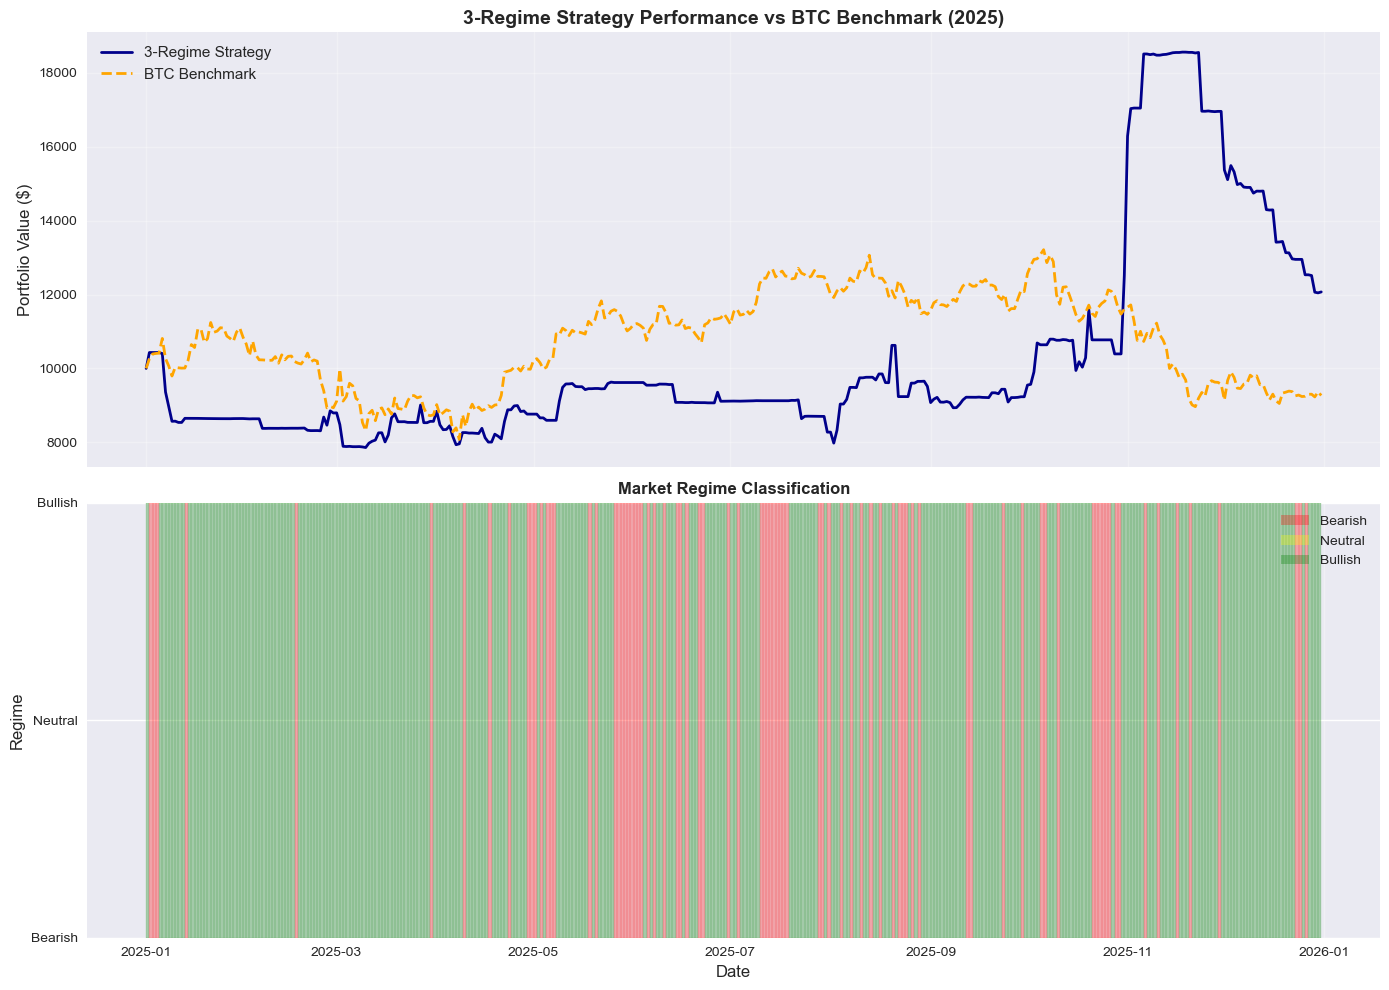

In [7]:
# Plot portfolio value over time with regime coloring
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Portfolio value
ax1.plot(res_3regime.index, res_3regime.values, label='3-Regime Strategy', linewidth=2, color='darkblue')
ax1.plot(btc_norm.index, btc_norm.values, label='BTC Benchmark', linewidth=2, linestyle='--', color='orange')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.set_title('3-Regime Strategy Performance vs BTC Benchmark (2025)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Regime visualization
regime_colors = {0: 'red', 1: 'yellow', 2: 'green'}
regime_labels = {0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}

for i, (date, regime) in enumerate(zip(test_dates[:-1], regime_hist)):
    ax2.axvspan(date, test_dates[i+1], alpha=0.3, color=regime_colors[regime])

ax2.set_ylabel('Regime', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Bearish', 'Neutral', 'Bullish'])
ax2.set_title('Market Regime Classification', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Legend for regime colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.3, label='Bearish'),
                   Patch(facecolor='yellow', alpha=0.3, label='Neutral'),
                   Patch(facecolor='green', alpha=0.3, label='Bullish')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

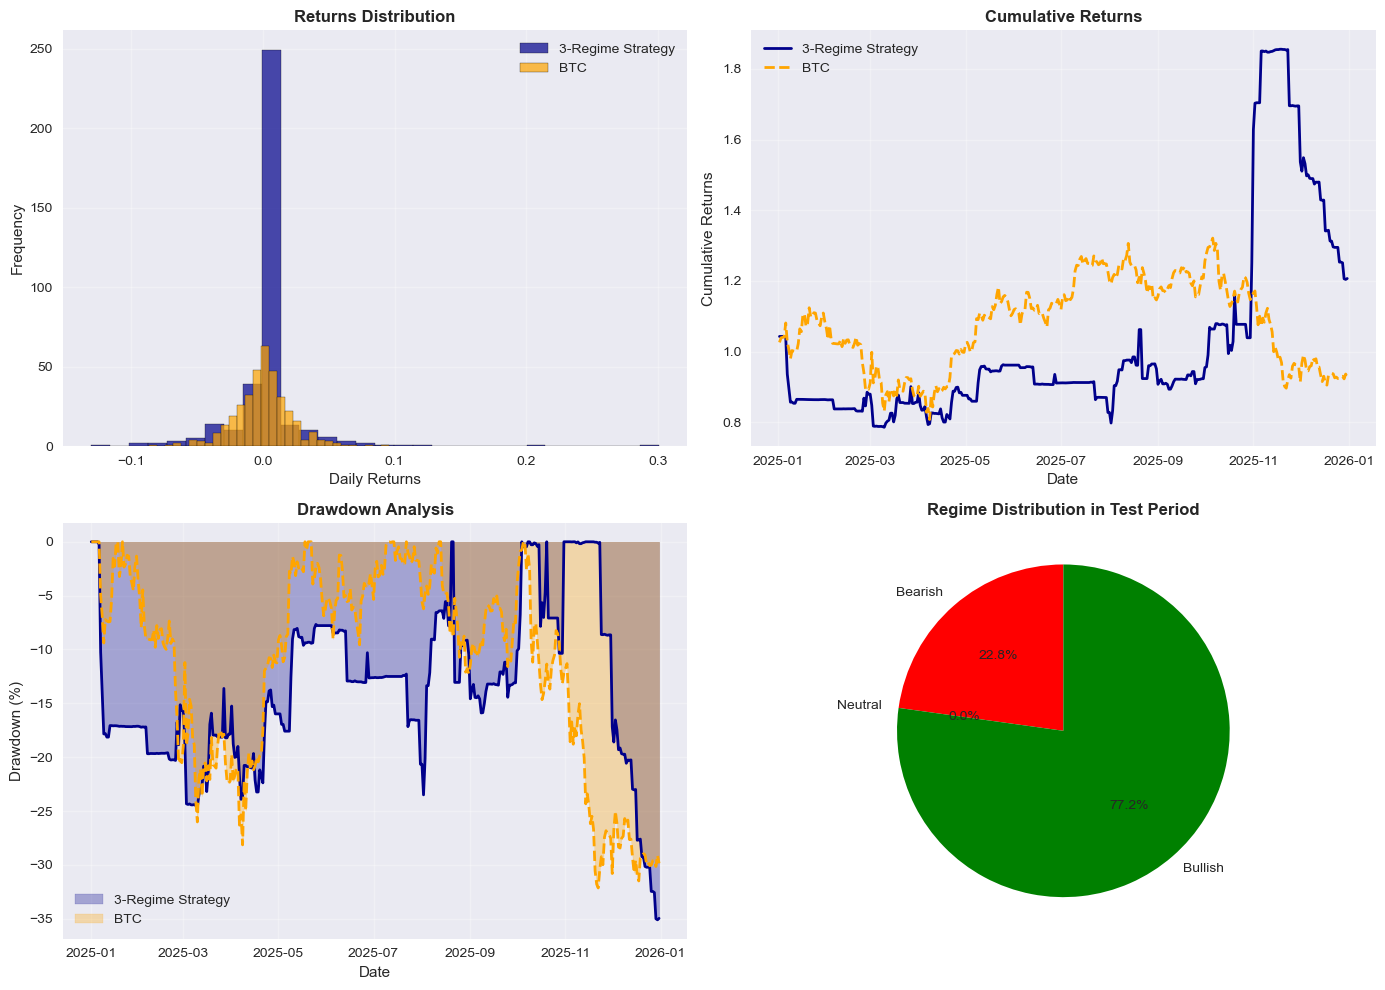

In [8]:
# Additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily returns distribution
returns_3regime = res_3regime.pct_change().dropna()
returns_btc = btc_norm.pct_change().dropna()

axes[0, 0].hist(returns_3regime, bins=30, alpha=0.7, label='3-Regime Strategy', edgecolor='black', color='darkblue')
axes[0, 0].hist(returns_btc, bins=30, alpha=0.7, label='BTC', edgecolor='black', color='orange')
axes[0, 0].set_xlabel('Daily Returns', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Returns Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Cumulative returns
cum_returns_3regime = (1 + returns_3regime).cumprod()
cum_returns_btc = (1 + returns_btc).cumprod()

axes[0, 1].plot(cum_returns_3regime.index, cum_returns_3regime.values, label='3-Regime Strategy', linewidth=2, color='darkblue')
axes[0, 1].plot(cum_returns_btc.index, cum_returns_btc.values, label='BTC', linewidth=2, linestyle='--', color='orange')
axes[0, 1].set_xlabel('Date', fontsize=11)
axes[0, 1].set_ylabel('Cumulative Returns', fontsize=11)
axes[0, 1].set_title('Cumulative Returns', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Drawdown
dd_3regime = (res_3regime / res_3regime.cummax() - 1) * 100
dd_btc = (btc_norm / btc_norm.cummax() - 1) * 100

axes[1, 0].fill_between(dd_3regime.index, dd_3regime.values, 0, alpha=0.3, color='darkblue', label='3-Regime Strategy')
axes[1, 0].plot(dd_3regime.index, dd_3regime.values, linewidth=2, color='darkblue')
axes[1, 0].fill_between(dd_btc.index, dd_btc.values, 0, alpha=0.3, color='orange', label='BTC')
axes[1, 0].plot(dd_btc.index, dd_btc.values, linewidth=2, color='orange', linestyle='--')
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].set_ylabel('Drawdown (%)', fontsize=11)
axes[1, 0].set_title('Drawdown Analysis', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Regime pie chart
regime_counts = pd.Series(regime_hist).value_counts().sort_index()
colors_pie = ['red', 'yellow', 'green']
labels_pie = ['Bearish', 'Neutral', 'Bullish']

axes[1, 1].pie([regime_counts.get(i, 0) for i in range(3)], 
               labels=labels_pie, 
               colors=colors_pie,
               autopct='%1.1f%%',
               startangle=90)
axes[1, 1].set_title('Regime Distribution in Test Period', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Summary

In [9]:
print("\n" + "="*70)
print("SUMMARY: 3-Regime Strategy (AI + Graph + Markowitz)")
print("="*70)
print(f"\n📊 Strategy Configuration:")
print(f"  🔴 Bearish Regime: 100% Cash (Risk-Off)")
print(f"  🟡 Neutral Regime: Markowitz on All Assets (Moderate Risk)")
print(f"  🟢 Bullish Regime: Graph Filter + Markowitz (Full Strategy)")
print(f"\n💰 Performance:")
print(f"  Initial Investment: $10,000")
print(f"  Final Value: ${metrics_3regime['Final Value']:,.2f}")
print(f"  Total Return: {metrics_3regime['Total Return (%)']:.2f}%")
print(f"  Sharpe Ratio: {metrics_3regime['Sharpe Ratio']:.2f}")
print(f"  Max Drawdown: {metrics_3regime['Max Drawdown (%)']:.2f}%")
print(f"\n📈 BTC Benchmark:")
print(f"  Final Value: ${metrics_btc['Final Value']:,.2f}")
print(f"  Total Return: {metrics_btc['Total Return (%)']:.2f}%")
print(f"\n🎯 Outperformance: {metrics_3regime['Total Return (%)'] - metrics_btc['Total Return (%)']:.2f}%")
print(f"\n📊 Regime Usage:")
for i, label in enumerate(['Bearish', 'Neutral', 'Bullish']):
    count = regime_counts.get(i, 0)
    pct = count / len(regime_hist) * 100
    print(f"  {label}: {count} days ({pct:.1f}%)")
print("="*70)


SUMMARY: 3-Regime Strategy (AI + Graph + Markowitz)

📊 Strategy Configuration:
  🔴 Bearish Regime: 100% Cash (Risk-Off)
  🟡 Neutral Regime: Markowitz on All Assets (Moderate Risk)
  🟢 Bullish Regime: Graph Filter + Markowitz (Full Strategy)

💰 Performance:
  Initial Investment: $10,000
  Final Value: $12,069.62
  Total Return: 20.70%
  Sharpe Ratio: 0.29
  Max Drawdown: -35.10%

📈 BTC Benchmark:
  Final Value: $9,268.06
  Total Return: -7.32%

🎯 Outperformance: 28.02%

📊 Regime Usage:
  Bearish: 83 days (22.8%)
  Neutral: 0 days (0.0%)
  Bullish: 281 days (77.2%)
